<a href="https://colab.research.google.com/github/AliSalimkhani/DeepNN_Course2025/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!apt-get update
!apt-get install -y build-essential cmake
!pip install ninja
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .

Looking in indexes: https://download.pytorch.org/whl/cu118
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem 

In [ ]:
!ls

assets		    docker-compose.yaml  pyproject.toml    setup.py
backend.Dockerfile  INSTALL.md		 README.md	   tools
checkpoints	    LICENSE		 RELEASE_NOTES.md  training
CODE_OF_CONDUCT.md  LICENSE_cctorch	 sam2
CONTRIBUTING.md     MANIFEST.in		 SAM_2.egg-info
demo		    notebooks		 sav_dataset


In [ ]:

%cd checkpoints
! ./download_ckpts.sh

/content/sam2/checkpoints
--2025-12-04 13:33:08--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.77, 65.8.76.35, 65.8.76.89, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_tiny.pt’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M   230MB/s    in 0.6s    

2025-12-04 13:33:08 (230 MB/s) - ‘sam2.1_hiera_tiny.pt’ saved [156008466/156008466]

--2025-12-04 13:33:08--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.77, 65.8.76.35, 65.8.76.89, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184416285 (176M)

In [ ]:
%cd ../../../../../content
!ls

/content
 frames    sam2		'Untitled video - Made with Clipchamp.mp4'
 run_sam   sample_data


In [ ]:
import cv2
import os

os.makedirs("frames", exist_ok=True)

cap = cv2.VideoCapture("Untitled video - Made with Clipchamp.mp4")
frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(f"frames/frame_{frame_id:04d}.jpg", frame)
    frame_id += 1

cap.release()

print("Extracted frames:", frame_id)


Extracted frames: 124


In [ ]:
import torch
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import numpy as np
from PIL import Image
import os

frames_dir = "/content/frames"
labels_dir = "/content/labels"

os.makedirs(labels_dir, exist_ok=True)


predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")

frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith(".jpg")])

print(f"تعداد کل فریم‌ها برای پردازش: {len(frame_files)}")

for i, frame_name in enumerate(frame_files):
    img_path = os.path.join(frames_dir, frame_name)

    label_path = os.path.join(labels_dir, frame_name.replace(".jpg", ".txt"))

    try:
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        img_height, img_width, _ = img_np.shape

        hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        lower_yellow = np.array([15, 80, 80])
        upper_yellow = np.array([40, 255, 255])
        yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)

        kernel_expand = np.ones((15, 15), np.uint8)
        yellow_mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel_expand)

        contours, _ = cv2.findContours(yellow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 50:
                x, y, w, h = cv2.boundingRect(c)
                sam_prompt_box = np.array([x, y, x + w, y + h])
                predictor.set_image(img_np)
                center_x, center_y = x + w // 2, y + h // 2
                input_point = np.array([[center_x, center_y]])
                input_label = np.array([1])

                masks, scores, logits = predictor.predict(
                    point_coords=input_point,
                    point_labels=input_label,
                    box=sam_prompt_box[None, :],
                    multimask_output=False
                )
                mask = masks[0]

                kernel = np.ones((5,5), np.uint8)
                mask_cleaned = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

                contours_final, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if contours_final:
                    x_final, y_final, w_final, h_final = cv2.boundingRect(contours_final[0])

                    # فرمت YOLO: <class_id> <x_center_norm> <y_center_norm> <width_norm> <height_norm>

                    class_id = 0
                    x_center_norm = (x_final + w_final / 2) / img_width
                    y_center_norm = (y_final + h_final / 2) / img_height
                    width_norm = w_final / img_width
                    height_norm = h_final / img_height

                    with open(label_path, 'w') as f:
                        f.write(f"{class_id} {x_center_norm} {y_center_norm} {width_norm} {height_norm}\n")

                    print(f"فریم {i+1}/{len(frame_files)}: {frame_name} - برچسب YOLO ذخیره شد.")
                else:
                    print(f"فریم {i+1}/{len(frame_files)}: {frame_name} - ماسک نهایی یافت نشد.")
            else:
                print(f"فریم {i+1}/{len(frame_files)}: {frame_name} - شیء زرد رنگی با مساحت کافی پیدا نشد.")
        else:
            print(f"فریم {i+1}/{len(frame_files)}: {frame_name} - هیچ شیء زرد رنگی در تصویر پیدا نشد.")

    except Exception as e:
        print(f"خطا در پردازش فریم {frame_name}: {e}")

print("\nپردازش تمام فریم‌ها به پایان رسید.")
print(f"برچسب‌های YOLO در پوشه {labels_dir} ذخیره شدند.")

در حال بارگذاری مدل SAM2...
مدل با موفقیت بارگذاری شد.
تعداد کل فریم‌ها برای پردازش: 124
فریم 1/124: frame_0000.jpg - برچسب YOLO ذخیره شد.
فریم 2/124: frame_0001.jpg - برچسب YOLO ذخیره شد.
فریم 3/124: frame_0002.jpg - برچسب YOLO ذخیره شد.
فریم 4/124: frame_0003.jpg - برچسب YOLO ذخیره شد.
فریم 5/124: frame_0004.jpg - برچسب YOLO ذخیره شد.
فریم 6/124: frame_0005.jpg - برچسب YOLO ذخیره شد.
فریم 7/124: frame_0006.jpg - برچسب YOLO ذخیره شد.
فریم 8/124: frame_0007.jpg - برچسب YOLO ذخیره شد.
فریم 9/124: frame_0008.jpg - برچسب YOLO ذخیره شد.
فریم 10/124: frame_0009.jpg - برچسب YOLO ذخیره شد.
فریم 11/124: frame_0010.jpg - برچسب YOLO ذخیره شد.
فریم 12/124: frame_0011.jpg - برچسب YOLO ذخیره شد.
فریم 13/124: frame_0012.jpg - برچسب YOLO ذخیره شد.
فریم 14/124: frame_0013.jpg - برچسب YOLO ذخیره شد.
فریم 15/124: frame_0014.jpg - برچسب YOLO ذخیره شد.
فریم 16/124: frame_0015.jpg - برچسب YOLO ذخیره شد.
فریم 17/124: frame_0016.jpg - برچسب YOLO ذخیره شد.
فریم 18/124: frame_0017.jpg - برچسب YOLO ذخیره شد.
فر

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

frames_dir = "/content/frames"
labels_dir = "/content/labels"
dataset_dir = "/content/yolo_dataset"

train_images_dir = os.path.join(dataset_dir, "images/train")
val_images_dir = os.path.join(dataset_dir, "images/val")
train_labels_dir = os.path.join(dataset_dir, "labels/train")
val_labels_dir = os.path.join(dataset_dir, "labels/val")

os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(val_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

all_files = sorted([f for f in os.listdir(frames_dir) if f.endswith(".jpg")])
random.shuffle(all_files)

split_index = int(0.8 * len(all_files))
train_files = all_files[:split_index]
val_files = all_files[split_index:]

print("در حال کپی کردن فایل‌های آموزش...")
for filename in tqdm(train_files):
    shutil.copy(os.path.join(frames_dir, filename), os.path.join(train_images_dir, filename))
    label_filename = filename.replace(".jpg", ".txt")
    shutil.copy(os.path.join(labels_dir, label_filename), os.path.join(train_labels_dir, label_filename))

print("\nدر حال کپی کردن فایل‌های ولیدیشن...")
for filename in tqdm(val_files):
    shutil.copy(os.path.join(frames_dir, filename), os.path.join(val_images_dir, filename))

    label_filename = filename.replace(".jpg", ".txt")
    shutil.copy(os.path.join(labels_dir, label_filename), os.path.join(val_labels_dir, label_filename))

print(f"\nتقسیم داده‌ها تمام شد!")
print(f"تعداد فایل‌های آموزش: {len(train_files)}")
print(f"تعداد فایل‌های اعتبارسنجی: {len(val_files)}")

در حال کپی کردن فایل‌های آموزش...


100%|██████████| 98/98 [00:00<00:00, 1265.09it/s]



در حال کپی کردن فایل‌های اعتبارسنجی...


100%|██████████| 25/25 [00:00<00:00, 2263.57it/s]


تقسیم داده‌ها تمام شد!
تعداد فایل‌های آموزش: 98
تعداد فایل‌های اعتبارسنجی: 25


In [ ]:

file_path = "/content/yolo_dataset/data.yaml"

yaml_content = """
train: images/train
val: images/val

# تعداد کلاس‌ها
nc: 1

# نام کلاس‌ها (به ترتیب شماره‌گذاری)
names:
  0: yellow_glue
"""
with open(file_path, "w") as f:
    f.write(yaml_content)

print(f"فایل YAML ساخته شد: {file_path}")


فایل YAML ساخته شد: /content/yolo_dataset/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')


results = model.train(
    data='/content/yolo_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo11n_yellow_glue_det',
    project='/content/runs/detect',
    device=0
)

print("آموزش مدل با موفقیت به پایان رسید!")
print(f"نتایج در مسیر زیر ذخیره شدند: {results.save_dir}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=F

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1203.5±252.5 MB/s, size: 86.0 KB)
train: Scanning /content/yolo_dataset/labels/train... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 2.3Kit/s 0.1s
train: New cache created: /content/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 586.9±445.1 MB/s, size: 88.4 KB)
val: Scanning /content/yolo_dataset/labels/val... 45 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 1.6Kit/s 0.0s
val: New cache created: /content/yolo_dataset/labels/val.cache
Plotting labels to /content/runs/detect/yolo11n_yellow_glue_det/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum'

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

       1/50        11G      1.209      4.682     0.9269         30        640: 0% ──────────── 0/8  8.9s

...

      49/50      4.96G     0.3764     0.6294     0.7766          8        640: 100% ━━━━━━━━━━━━ 8/8 4.8it/s 1.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.9it/s 0.3s
                   all         46         45      0.999          1      0.995      0.935

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

      50/50      4.96G     0.5122     0.6706     0.8847         16        640: 0% ──────────── 0/8  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      4.97G     0.3977     0.6057     0.8141          8        640: 100% ━━━━━━━━━━━━ 8/8 2.0it/s 3.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.7it/s 0.4s
                   all         46         45      0.999          1      0.995      0.939

50 epochs completed in 0.046 hours.
Optimizer stripped from /content/runs/detect/yolo11n_yellow_glue_det/weights/last.pt, 5.4MB
Optimizer stripped from /content/runs/detect/yolo11n_yellow_glue_det/weights/best.pt, 5.4MB

Validating /content/runs/detect/yolo11n_yellow_glue_det/weights/best.pt...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.1it/s 0.5s
                   all         46         45          1      0.997      0.995       


image 1/1 /content/frames/frame_0005.jpg: 384x640 1 yellow_glue, 22.1ms
Speed: 2.1ms preprocess, 22.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


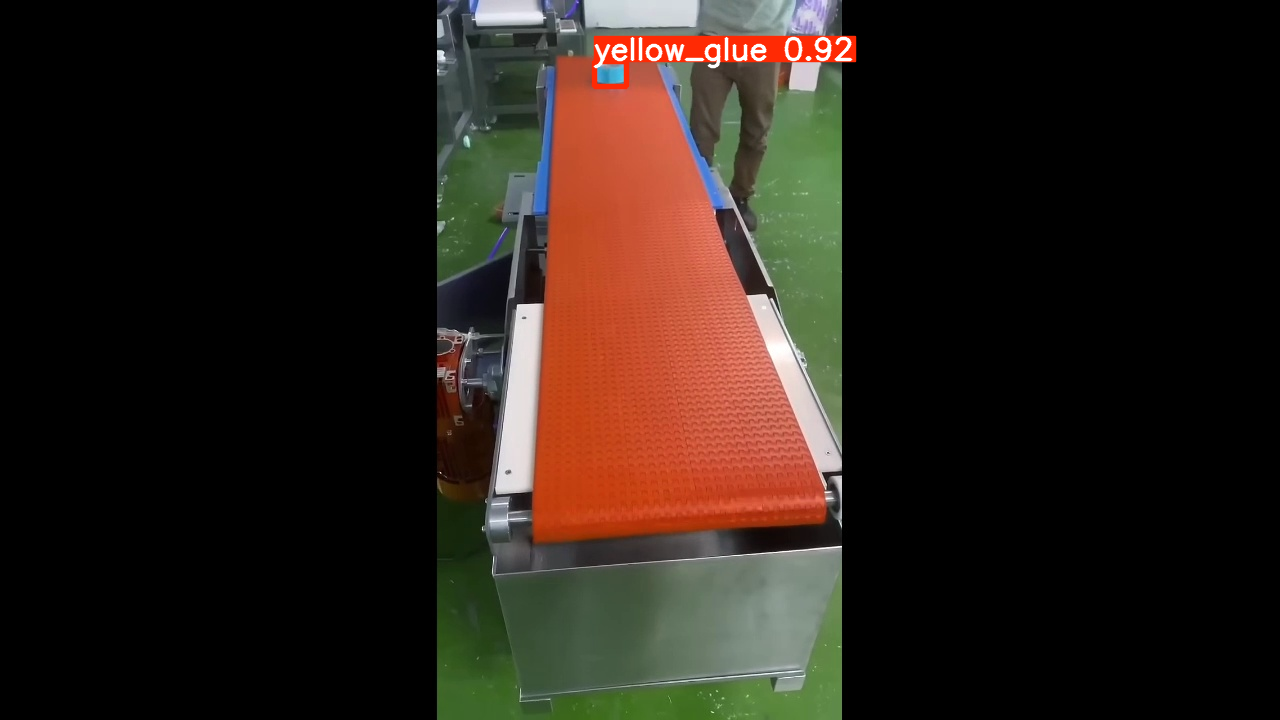

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow


trained_model = YOLO('/content/runs/detect/yolo11n_yellow_glue_det/weights/best.pt')


test_image_path = "/content/frames/frame_0005.jpg"


results = trained_model.predict(test_image_path, conf=0.5)


for r in results:
    im_array = r.plot()
    im = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    cv2_imshow(im)

In [ ]:
from ultralytics import YOLO
import cv2


model = YOLO('/content/runs/detect/yolo11n_yellow_glue_det/weights/best.pt')


input_video_path = "/content/Untitled video - Made with Clipchamp.mp4" # مسیر ویدیوی شما
output_video_path = "/content/output_video_with_detections.mp4"


cap = cv2.VideoCapture(input_video_path)


fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))


frame_count = 0
while cap.isOpened():
    success, frame = cap.read()

    if not success:
        print("پردازش ویدیو به پایان رسید.")
        break


    results = model.predict(frame, verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]
            cls = int(box.cls[0])
            class_name = model.names[cls]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f'{class_name}: {confidence:.2f}'
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)


    out.write(frame)

    frame_count += 1
    print(f"در حال پردازش فریم {frame_count}...")

cap.release()
out.release()

print(f"\nویدیوی خروجی با موفقیت در مسیر زیر ذخیره شد:")
print(output_video_path)

در حال پردازش فریم 1...
در حال پردازش فریم 2...
در حال پردازش فریم 3...
در حال پردازش فریم 4...
در حال پردازش فریم 5...
در حال پردازش فریم 6...
در حال پردازش فریم 7...
در حال پردازش فریم 8...
در حال پردازش فریم 9...
در حال پردازش فریم 10...
در حال پردازش فریم 11...
در حال پردازش فریم 12...
در حال پردازش فریم 13...
در حال پردازش فریم 14...
در حال پردازش فریم 15...
در حال پردازش فریم 16...
در حال پردازش فریم 17...
در حال پردازش فریم 18...
در حال پردازش فریم 19...
در حال پردازش فریم 20...
در حال پردازش فریم 21...
در حال پردازش فریم 22...
در حال پردازش فریم 23...
در حال پردازش فریم 24...
در حال پردازش فریم 25...
در حال پردازش فریم 26...
در حال پردازش فریم 27...
در حال پردازش فریم 28...
در حال پردازش فریم 29...
در حال پردازش فریم 30...
در حال پردازش فریم 31...
در حال پردازش فریم 32...
در حال پردازش فریم 33...
در حال پردازش فریم 34...
در حال پردازش فریم 35...
در حال پردازش فریم 36...
در حال پردازش فریم 37...
در حال پردازش فریم 38...
در حال پردازش فریم 39...
در حال پردازش فریم 40...
در حال پر

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from scipy.spatial import distance as dist
from collections import OrderedDict



class CentroidTracker:
    def __init__(self, maxDisappeared=50):
        self.nextObjectID = 0
        self.objects = OrderedDict()
        self.disappeared = OrderedDict()
        self.maxDisappeared = maxDisappeared

    def register(self, centroid):
        self.objects[self.nextObjectID] = centroid
        self.disappeared[self.nextObjectID] = 0
        self.nextObjectID += 1

    def deregister(self, objectID):
        del self.objects[objectID]
        del self.disappeared[objectID]

    def update(self, rects):
        if len(rects) == 0:
            for objectID in list(self.disappeared.keys()):
                self.disappeared[objectID] += 1
                if self.disappeared[objectID] > self.maxDisappeared:
                    self.deregister(objectID)
            return self.objects

        inputCentroids = np.zeros((len(rects), 2), dtype="int")
        for (i, (startX, startY, endX, endY)) in enumerate(rects):
            cX = int((startX + endX) / 2.0)
            cY = int((startY + endY) / 2.0)
            inputCentroids[i] = (cX, cY)

        if len(self.objects) == 0:
            for i in range(len(inputCentroids)):
                self.register(inputCentroids[i])
        else:
            objectIDs = list(self.objects.keys())
            objectCentroids = list(self.objects.values())

            D = dist.cdist(np.array(objectCentroids), inputCentroids)
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]

            usedRows = set()
            usedCols = set()

            for (row, col) in zip(rows, cols):
                if row in usedRows or col in usedCols:
                    continue
                objectID = objectIDs[row]
                self.objects[objectID] = inputCentroids[col]
                self.disappeared[objectID] = 0
                usedRows.add(row)
                usedCols.add(col)

            unusedRows = set(range(0, D.shape[0])).difference(usedRows)
            unusedCols = set(range(0, D.shape[1])).difference(usedCols)

            if D.shape[0] >= D.shape[1]:
                for row in unusedRows:
                    objectID = objectIDs[row]
                    self.disappeared[objectID] += 1
                    if self.disappeared[objectID] > self.maxDisappeared:
                        self.deregister(objectID)
            else:
                for col in unusedCols:
                    self.register(inputCentroids[col])

        return self.objects


model = YOLO('/content/runs/detect/yolo11n_yellow_glue_det/weights/best.pt')


input_video_path = "/content/Untitled video - Made with Clipchamp.mp4"
output_video_path = "/content/output_video_with_counting.mp4"

cap = cv2.VideoCapture(input_video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

COUNT_LINE_Y = height // 2
line_start_point = (0, COUNT_LINE_Y)
line_end_point = (width, COUNT_LINE_Y)

ct = CentroidTracker(maxDisappeared=20)
object_count = 0
counted_objects = set()

print("شروع پردازش ویدیو برای شمارش اشیاء...")

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("پردازش ویدیو به پایان رسید.")
        break

    results = model.predict(frame, verbose=False)

    rects = []
    for r in results:
        boxes = r.boxes
        for box in boxes:
            cls = int(box.cls[0])
            if model.names[cls] == 'yellow_glue':
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                rects.append((x1, y1, x2, y2))

    objects = ct.update(rects)

    for (objectID, centroid) in objects.items():
        for (x1, y1, x2, y2) in rects:
            cX = (x1 + x2) // 2
            cY = (y1 + y2) // 2
            if abs(cX - centroid[0]) < 5 and abs(cY - centroid[1]) < 5:
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"ID {objectID}", (centroid[0] - 10, centroid[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                break

        if objectID not in counted_objects:
            if centroid[1] > COUNT_LINE_Y:
                object_count += 1
                counted_objects.add(objectID)
                print(f"فریم {frame_count}: شیء با ID {objectID} عبور کرد. تعداد کل: {object_count}")

    cv2.line(frame, line_start_point, line_end_point, (0, 0, 255), 2)
    cv2.putText(frame, f"Count: {object_count}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    out.write(frame)

    frame_count += 1

cap.release()
out.release()

print(f"\nپردازش تمام شد.")
print(f"ویدیوی خروجی با موفقیت در مسیر زیر ذخیره شد:")
print(output_video_path)

شروع پردازش ویدیو برای شمارش اشیاء...
فریم 104: شیء با ID 0 عبور کرد. تعداد کل: 1
پردازش ویدیو به پایان رسید.

پردازش تمام شد.
ویدیوی خروجی با موفقیت در مسیر زیر ذخیره شد:
/content/output_video_with_counting.mp4
